<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Ridge_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_diabetes

data=load_diabetes()

In [ ]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [ ]:
X=data.data
y=data.target

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [ ]:
from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [ ]:
L.fit(X_train,y_train)

LinearRegression()

In [ ]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [ ]:
y_pred=L.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539249
RMSE 48.72713760953253


In [ ]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=100000)

In [ ]:
R.fit(X_train,y_train)

Ridge(alpha=100000)

In [ ]:
print(R.coef_)
print(R.intercept_)

[ 0.00260126  0.00057066  0.00776597  0.0060976   0.00233864  0.00184724
 -0.00513942  0.0052716   0.00734598  0.00528629]
151.83287930791352


In [ ]:
y_pred1=R.predict(X_test)

In [ ]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score -0.00042490200441935855
RMSE 70.25956272917782


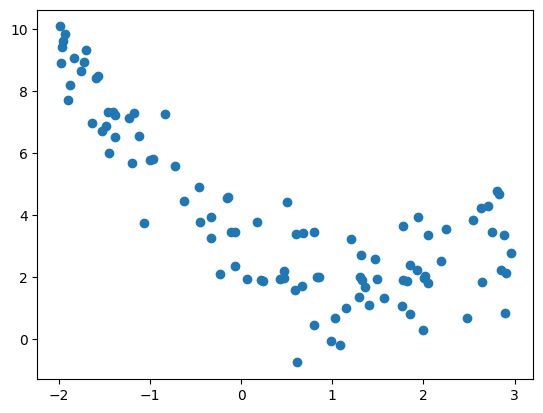

In [ ]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

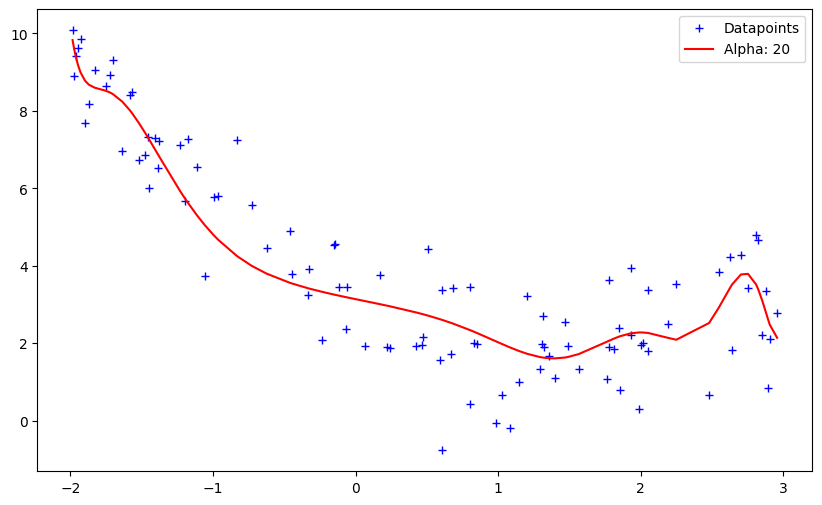

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [ 20]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
X=data.data
y=data.target

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [ ]:
from sklearn.linear_model import ridge_regression


In [ ]:
lr=Ridge(alpha=10)

In [ ]:
lr.fit(X_train,y_train)


Ridge(alpha=10)

In [ ]:
pred=lr.predict(X_test)

R2 score with Ridge (alpha=100): 0.025224686457473333


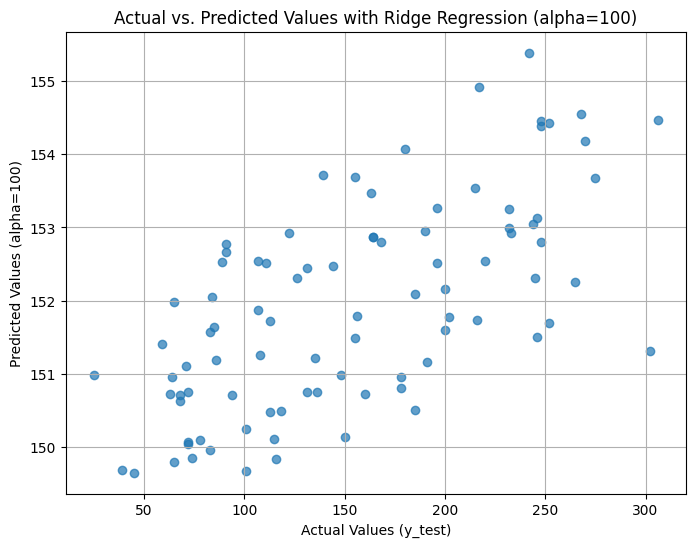

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Instantiate Ridge regression with alpha=100
ridge_model = Ridge(alpha=100)

# Fit the model to the training data
ridge_model.fit(X_train, y_train)

# Make predictions on the test data
pred_alpha_100 = ridge_model.predict(X_test)

# Calculate R2 score
r2 = r2_score(y_test, pred_alpha_100)
print(f"R2 score with Ridge (alpha=100): {r2}")

# Generate scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_alpha_100, alpha=0.7)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (alpha=100)")
plt.title("Actual vs. Predicted Values with Ridge Regression (alpha=100)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for alpha
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# Create a Ridge regression model instance
ridge = Ridge()

# Create a GridSearchCV object
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best alpha and its corresponding R2 score
print(f"Best alpha found: {grid_search.best_params_['alpha']}")
print(f"Best R2 score with best alpha: {grid_search.best_score_}")

Best alpha found: 0.1
Best R2 score with best alpha: 0.4553741083414146


R2 score with best Ridge (alpha=0.1): 0.5208421054129915


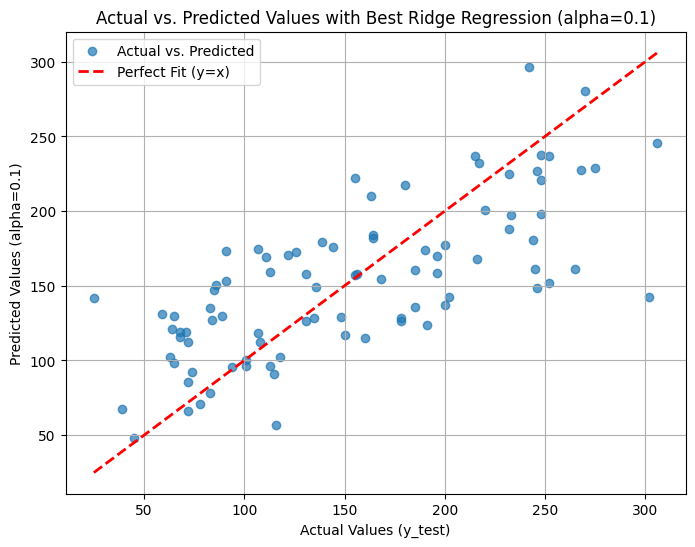

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Train a Ridge model with the best alpha found (0.1)
best_ridge_model = Ridge(alpha=0.1)
best_ridge_model.fit(X_train, y_train)

# Make predictions using the best model
pred_best_alpha = best_ridge_model.predict(X_test)

# Calculate R2 score for the best alpha
r2_best_alpha = r2_score(y_test, pred_best_alpha)
print(f"R2 score with best Ridge (alpha=0.1): {r2_best_alpha}")

# Generate scatter plot with best fit line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_best_alpha, alpha=0.7, label='Actual vs. Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit (y=x)')
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (alpha=0.1)")
plt.title("Actual vs. Predicted Values with Best Ridge Regression (alpha=0.1)")
plt.grid(True)
plt.legend()
plt.show()

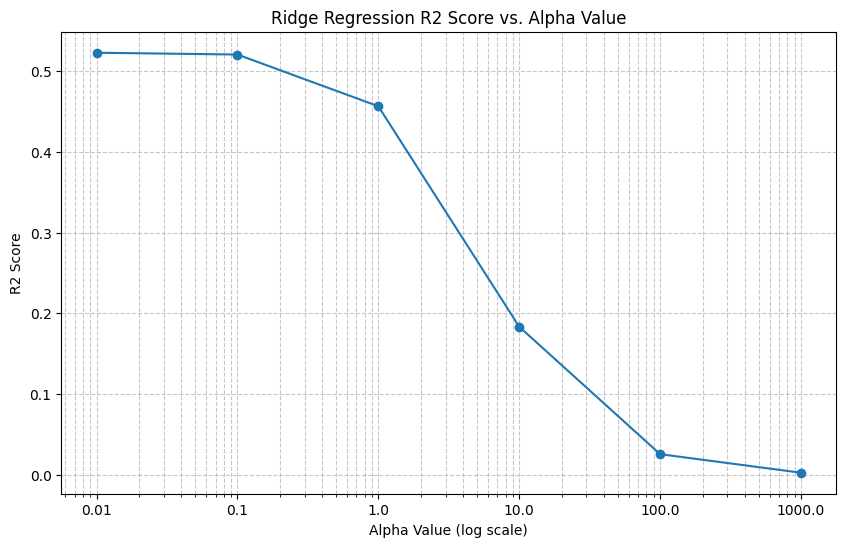

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Define the parameter grid for alpha (re-using the one from GridSearchCV)
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
r2_scores_per_alpha = []

for alpha in alpha_values:
    ridge_model_temp = Ridge(alpha=alpha)
    ridge_model_temp.fit(X_train, y_train)
    y_pred_temp = ridge_model_temp.predict(X_test)
    r2 = r2_score(y_test, y_pred_temp)
    r2_scores_per_alpha.append(r2)

plt.figure(figsize=(10, 6))
plt.plot(alpha_values, r2_scores_per_alpha, marker='o', linestyle='-')
plt.xscale('log') # Use log scale for alpha values
plt.xlabel('Alpha Value (log scale)')
plt.ylabel('R2 Score')
plt.title('Ridge Regression R2 Score vs. Alpha Value')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.xticks(alpha_values, labels=[str(a) for a in alpha_values]) # Set custom ticks for clarity
plt.show()

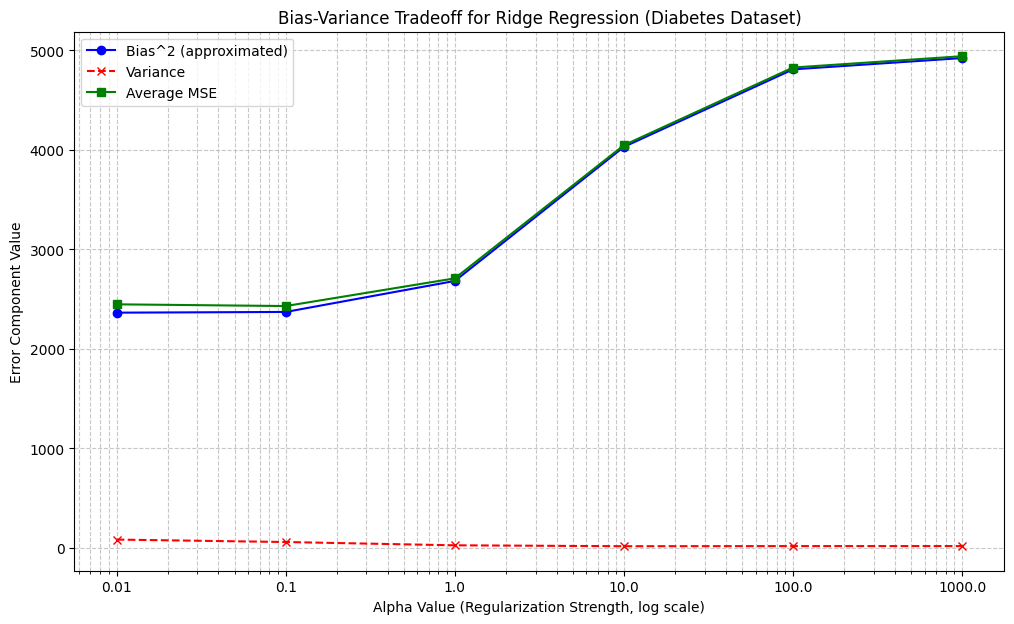

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.utils import resample # for bootstrapping

# Define a range of alpha values for Ridge regularization
# Using similar values as in the R2 score plot to compare
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

n_bootstraps = 100 # Number of bootstrap samples

# Lists to store calculated bias, variance, and MSE for each alpha
bias_squared_list = []
variance_list = []
mse_list = []

# Loop over each alpha value
for alpha in alpha_values:
    # Store predictions from multiple bootstrapped models for current alpha
    all_predictions_for_alpha = []
    mse_per_bootstrap = []

    # Perform bootstrapping
    for i in range(n_bootstraps):
        # Create a bootstrap sample from the training data
        X_boot, y_boot = resample(X_train, y_train, random_state=i) # Using random_state for reproducibility

        # Train a Ridge model on the bootstrap sample
        model = Ridge(alpha=alpha)
        model.fit(X_boot, y_boot)

        # Make predictions on the original test set
        y_pred = model.predict(X_test)
        all_predictions_for_alpha.append(y_pred)

        # Calculate MSE for this bootstrap model on the test set
        mse_per_bootstrap.append(np.mean((y_test - y_pred)**2))

    # Convert list of predictions to a NumPy array for easier calculations
    all_predictions_for_alpha = np.array(all_predictions_for_alpha)

    # Calculate average predictions across bootstraps for each test point
    average_predictions = np.mean(all_predictions_for_alpha, axis=0)

    # Calculate Bias^2: (y_test - E[y_pred])^2, averaged over test set
    # This includes the irreducible error when using y_test as the 'true' value
    bias_squared_for_alpha = np.mean((y_test - average_predictions)**2)
    bias_squared_list.append(bias_squared_for_alpha)

    # Calculate Variance: E[(y_pred - E[y_pred])^2], averaged over test set
    variance_for_alpha = np.mean(np.var(all_predictions_for_alpha, axis=0))
    variance_list.append(variance_for_alpha)

    # Store the average MSE from the bootstrapped models
    mse_list.append(np.mean(mse_per_bootstrap))


# Plotting the bias-variance tradeoff
plt.figure(figsize=(12, 7))

plt.plot(alpha_values, bias_squared_list, marker='o', linestyle='-', color='blue', label='Bias^2 (approximated)')
plt.plot(alpha_values, variance_list, marker='x', linestyle='--', color='red', label='Variance')
plt.plot(alpha_values, mse_list, marker='s', linestyle='-', color='green', label='Average MSE')

plt.xscale('log') # Use log scale for alpha values
plt.xlabel('Alpha Value (Regularization Strength, log scale)')
plt.ylabel('Error Component Value')
plt.title('Bias-Variance Tradeoff for Ridge Regression (Diabetes Dataset)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.xticks(alpha_values, labels=[str(a) for a in alpha_values]) # Set custom ticks for clarity
plt.show()